# Deep Q-Network (DQN)

### Onde estamos na jornada?

| Aula | Algoritmo | Como aprende? | Limitação |
|---|---|---|---|
| 1 | **MDP / Value Iteration** | Cálculo matemático (conhece o ambiente) | Precisa conhecer P(s'\|s,a) |
| 2 | **Q-Learning** | Tabela Q(s,a) por tentativa e erro | Tabela explode com espaços grandes |
| 3 | **DQN** ← hoje | Rede neural aproxima Q(s,a) | Precisa de mais dado e truques de estabilidade |

### O problema do Q-Learning clássico

Um jogo de Atari tem telas de 210×160 pixels com 256 cores — o número de estados possíveis é astronomicamente grande. Uma tabela Q é inviável.

### A solução do DQN

Substituir a tabela por uma **rede neural** que *aprende a função* Q(s,a):

```
         ┌─────────────────────┐
estado s →│   Rede Neural       │→ [Q(s, ↑), Q(s, ↓), Q(s, ←), Q(s, →)]
         └─────────────────────┘
```

Mas só trocar a tabela pela rede **não funciona** — o treinamento diverge.  
O DQN adiciona dois truques que tornam tudo estável:

| Truque | O que faz | Por que é necessário |
|---|---|---|
| **Experience Replay** | Guarda experiências passadas e treina em batches aleatórios | Quebra a correlação temporal dos dados |
| **Target Network** | Usa uma cópia congelada da rede para calcular os alvos | Evita perseguir um alvo que muda a todo instante |

---
## 1. Instalação e Importações

In [20]:
# PyTorch é a única dependência extra
# !pip install torch --quiet

import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

from IPython.display import clear_output

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Pronto! Usando: {device}')
print(f'PyTorch versão: {torch.__version__}')

Pronto! Usando: cuda
PyTorch versão: 2.10.0+cu128


---
## 2. O Ambiente — Labirinto com Estado Numérico

Para o DQN, o estado precisa ser um **vetor numérico** (entrada da rede neural).  
Usamos o mesmo labirinto das aulas anteriores, mas representamos o estado como:

```
estado = [linha_normalizada, coluna_normalizada]   → vetor de tamanho 2
```

Em problemas reais (Atari, robótica), o estado seria pixels ou sensores — muito maior.

In [7]:
# Labirinto: 0=livre  1=parede  2=armadilha  3=objetivo
MAZE = np.array([
    [0, 0, 0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 1, 0],
    [0, 0, 0, 1, 2, 0, 0],
    [1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 2],
    [0, 1, 1, 1, 0, 0, 3],
])

ROWS, COLS = MAZE.shape
START = (0, 0)
GOAL  = (6, 6)

REWARDS      = {0: -1, 2: -10, 3: +20}
ACTIONS      = [0, 1, 2, 3]
ACTION_NAMES  = {0:'Cima', 1:'Baixo', 2:'Esquerda', 3:'Direita'}
ACTION_ARROWS = {0:'↑',    1:'↓',    2:'←',         3:'→'}
ACTION_DELTAS = {0:(-1,0), 1:(1,0),  2:(0,-1),       3:(0,1)}

N_STATES  = 2            # [linha, coluna] normalizados
N_ACTIONS = len(ACTIONS)


def encode_state(state):
    """Converte (row, col) para tensor normalizado [0,1] — entrada da rede."""
    r, c = state
    return torch.tensor([r / (ROWS - 1), c / (COLS - 1)],
                        dtype=torch.float32, device=device)


def step(state, action):
    """Executa uma ação e retorna (próximo_estado, recompensa, fim?)."""
    r, c   = state
    dr, dc = ACTION_DELTAS[action]
    nr, nc = r + dr, c + dc
    if nr < 0 or nr >= ROWS or nc < 0 or nc >= COLS or MAZE[nr, nc] == 1:
        nr, nc = r, c
    next_state = (nr, nc)
    cell       = MAZE[nr, nc]
    reward     = REWARDS.get(cell, -1)
    done       = (next_state == GOAL) or (cell == 2)
    return next_state, reward, done


# Exemplo de codificação
print('Exemplo de encode_state:')
print(f'  Estado (0,0) → tensor: {encode_state((0,0))}')
print(f'  Estado (6,6) → tensor: {encode_state((6,6))}')
print(f'\nTamanho da entrada da rede: {N_STATES} neurônios')
print(f'Tamanho da saída da rede  : {N_ACTIONS} neurônios (um Q-value por ação)')

Exemplo de encode_state:
  Estado (0,0) → tensor: tensor([0., 0.], device='cuda:0')
  Estado (6,6) → tensor: tensor([1., 1.], device='cuda:0')

Tamanho da entrada da rede: 2 neurônios
Tamanho da saída da rede  : 4 neurônios (um Q-value por ação)


---
## 3. A Rede Neural — Aproximando Q(s, a)

A rede recebe o estado e retorna os Q-values de todas as ações simultaneamente:

```
 Entrada         Camada 1      Camada 2       Saída
[row, col]  →  [64 neurônios] → [64 neurônios] → [Q(↑), Q(↓), Q(←), Q(→)]
  (2)              ReLU            ReLU              (4)
```

Usamos **ReLU** como ativação (exceto na saída, que é linear — Q-values podem ser negativos).

In [8]:
class QNetwork(nn.Module):
    """
    Rede neural que aproxima a função Q(s, a).

    Entrada : estado codificado (2 valores normalizados)
    Saída   : Q-value para cada ação possível (4 valores)
    """
    def __init__(self, n_states, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden),   # Camada de entrada
            nn.ReLU(),
            nn.Linear(hidden, hidden),     # Camada oculta
            nn.ReLU(),
            nn.Linear(hidden, n_actions),  # Saída: um Q-value por ação
        )

    def forward(self, x):
        return self.net(x)


# Instancia e exibe a arquitetura
demo_net = QNetwork(N_STATES, N_ACTIONS).to(device)
print('Arquitetura da Q-Network:')
print(demo_net)
print()

# Conta os parâmetros
n_params = sum(p.numel() for p in demo_net.parameters())
print(f'Total de parâmetros treináveis: {n_params:,}')
print()

# Teste de passagem (forward pass)
estado_teste = encode_state((0, 0)).unsqueeze(0)  # batch de 1
q_vals_teste = demo_net(estado_teste)
print('Teste — Q-values para o estado inicial (0,0) [rede não treinada]:')
for i, a in enumerate(ACTIONS):
    print(f'  Q(s, {ACTION_ARROWS[a]}) = {q_vals_teste[0,i].item():.4f}')

Arquitetura da Q-Network:
QNetwork(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)

Total de parâmetros treináveis: 4,612

Teste — Q-values para o estado inicial (0,0) [rede não treinada]:
  Q(s, ↑) = -0.1265
  Q(s, ↓) = -0.0679
  Q(s, ←) = -0.0995
  Q(s, →) = -0.1297


---
## 4. Truque 1 — Experience Replay (Memória de Experiências)

### O problema sem Experience Replay

Se treinarmos com a experiência imediata `(s, a, r, s')`, os dados são:
- **Correlacionados**: estado 5 depende do estado 4, que depende do 3...
- **Não-estacionários**: a distribuição muda conforme a política melhora

Redes neurais treinadas com dados correlacionados divergem ou ficam presas em mínimos locais.

### A solução

Guardar as experiências em um **buffer circular** e amostrar **minibatches aleatórios**:

```
Buffer:  [(s1,a1,r1,s1'), (s2,a2,r2,s2'), ..., (sN,aN,rN,sN')]
              ↑ adiciona novas              ↑ amostras aleatórias para treinar
```

In [9]:
class ReplayBuffer:
    """
    Buffer circular que armazena experiências passadas.
    Cada experiência = (estado, ação, recompensa, próximo_estado, fim?)
    """
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)  # descarta as mais antigas quando cheio

    def push(self, state, action, reward, next_state, done):
        """Adiciona uma experiência ao buffer."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Retorna um minibatch aleatório de experiências."""
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.stack(states),
            torch.tensor(actions,  dtype=torch.long,  device=device),
            torch.tensor(rewards,  dtype=torch.float32, device=device),
            torch.stack(next_states),
            torch.tensor(dones,    dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)


# Demonstração
demo_buffer = ReplayBuffer(capacity=10)
for i in range(8):
    s  = encode_state((i % ROWS, i % COLS))
    ns = encode_state(((i+1) % ROWS, (i+1) % COLS))
    demo_buffer.push(s, i % 4, -1, ns, False)

print(f'Buffer com {len(demo_buffer)} experiências.')
batch = demo_buffer.sample(3)
print(f'Minibatch amostrado — estados shape: {batch[0].shape}')
print(f'  ações  : {batch[1].tolist()}')
print(f'  recomp.: {batch[2].tolist()}')

Buffer com 8 experiências.
Minibatch amostrado — estados shape: torch.Size([3, 2])
  ações  : [1, 0, 1]
  recomp.: [-1.0, -1.0, -1.0]


---
## 5. Truque 2 — Target Network (Rede Alvo)

### O problema sem Target Network

A equação de Bellman tem dois lados:

```
Q(s,a)  ←  r + γ · max Q(s', a')
  ↑                      ↑
o que queremos        o alvo
atualizar
```

Se usarmos **a mesma rede** para calcular o alvo e fazer a atualização, o alvo se move a cada passo — é como tentar acertar um alvo em movimento. O treinamento oscila e pode divergir.

### A solução

Manter **duas redes** com os mesmos pesos:
- **Q-Network** (`q_net`): atualizada a cada passo de treinamento
- **Target Network** (`target_net`): cópia congelada, copiada da `q_net` a cada C passos

```
                       ┌──────────────────────────┐
                       │  a cada C episódios       │
                       │  target_net ← q_net       │
                       └──────────────────────────┘
                                    ↑
q_net (treina todo passo)    target_net (congelada)
calcula Q(s,a)               calcula max Q(s',a') — o alvo
```

In [11]:
import copy

def criar_redes():
    """Cria a Q-network e a Target network (cópia idêntica, mas independente)."""
    q_net      = QNetwork(N_STATES, N_ACTIONS).to(device)
    target_net = copy.deepcopy(q_net)         # Cópia exata dos pesos
    target_net.eval()                          # Modo de inferência (sem gradiente)
    return q_net, target_net


def atualizar_target(q_net, target_net):
    """Copia os pesos da q_net para a target_net."""
    target_net.load_state_dict(q_net.state_dict())


# Verifica que as redes começam iguais e ficam diferentes após treino
q_net, target_net = criar_redes()

estado_t = encode_state((3, 3)).unsqueeze(0)
q_antes   = q_net(estado_t).detach().cpu().numpy()
tgt_antes = target_net(estado_t).detach().cpu().numpy()

print('Q-values para estado (3,3) — antes do treinamento:')
print(f'  Q-Network   : {q_antes[0].round(4)}')
print(f'  Target Net  : {tgt_antes[0].round(4)}')
print(f'  Iguais?     : {np.allclose(q_antes, tgt_antes)}')
print()
print('→ A Target Network só será atualizada a cada C episódios.')
print('  Isso estabiliza os alvos de treinamento.')

Q-values para estado (3,3) — antes do treinamento:
  Q-Network   : [ 0.0144 -0.0254  0.0649  0.0708]
  Target Net  : [ 0.0144 -0.0254  0.0649  0.0708]
  Iguais?     : True

→ A Target Network só será atualizada a cada C episódios.
  Isso estabiliza os alvos de treinamento.


---
## 6. A Função de Treinamento — Juntando Tudo

A cada passo de treinamento:

1. Amostra um batch do replay buffer
2. Calcula **Q atual** com a `q_net`: `Q(s, a)`
3. Calcula **Q alvo** com a `target_net`: `r + γ · max Q(s', a')`
4. Calcula o erro (loss = MSE entre atual e alvo)
5. Retropropaga e atualiza os pesos da `q_net`

In [12]:
def treinar_passo(q_net, target_net, optimizer, buffer, batch_size, gamma):
    """
    Executa um passo de treinamento do DQN.
    Retorna o valor do loss (para monitoramento).
    """
    if len(buffer) < batch_size:
        return None  # Aguarda o buffer ter dados suficientes

    # 1) Amostra um minibatch aleatório
    states, actions, rewards, next_states, dones = buffer.sample(batch_size)

    # 2) Q atual: Q(s, a) — só para as ações que foram tomadas
    q_atual = q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    # 3) Q alvo: r + γ · max_a' Q_target(s', a')
    #    Se done=True (episódio acabou), o alvo é só r (sem futuro)
    with torch.no_grad():
        q_prox = target_net(next_states).max(1)[0]
        q_alvo = rewards + gamma * q_prox * (1 - dones)

    # 4) Loss = erro quadrático médio entre atual e alvo
    loss = nn.MSELoss()(q_atual, q_alvo)

    # 5) Retropropagação
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


print('✅ Função de treinamento definida!')
print()
print('Resumo do fluxo DQN:')
print('  Agente age  → coleta (s, a, r, s\') → salva no buffer')
print('  A cada passo → amostra batch → calcula loss → atualiza q_net')
print('  A cada C ep. → copia q_net → target_net')

✅ Função de treinamento definida!

Resumo do fluxo DQN:
  Agente age  → coleta (s, a, r, s') → salva no buffer
  A cada passo → amostra batch → calcula loss → atualiza q_net
  A cada C ep. → copia q_net → target_net


---
## 7. Treinamento Completo do DQN

In [21]:
N_EPISODES       = 1500    # Total de episódios
MAX_STEPS        = 150     # Limite de passos por episódio
GAMMA            = 0.95    # Fator de desconto
LR               = 1e-3    # Taxa de aprendizado da rede
BATCH_SIZE       = 64      # Tamanho do minibatch
BUFFER_SIZE      = 10_000  # Capacidade do replay buffer
TARGET_UPDATE    = 20      # Atualiza target_net a cada N episódios
EPS_START        = 1.0     # Epsilon inicial
EPS_MIN          = 0.05    # Epsilon mínimo
EPS_DECAY        = 0.995   # Decaimento por episódio

print('Hiperparâmetros DQN:')
for nome, val in [('Episódios', N_EPISODES), ('γ (gamma)', GAMMA),
                   ('LR (alpha)', LR), ('Batch size', BATCH_SIZE),
                   ('Buffer size', BUFFER_SIZE),
                   ('Target update (ep)', TARGET_UPDATE)]:
    print(f'  {nome:<22}: {val}')

Hiperparâmetros DQN:
  Episódios             : 1500
  γ (gamma)             : 0.95
  LR (alpha)            : 0.001
  Batch size            : 64
  Buffer size           : 10000
  Target update (ep)    : 20


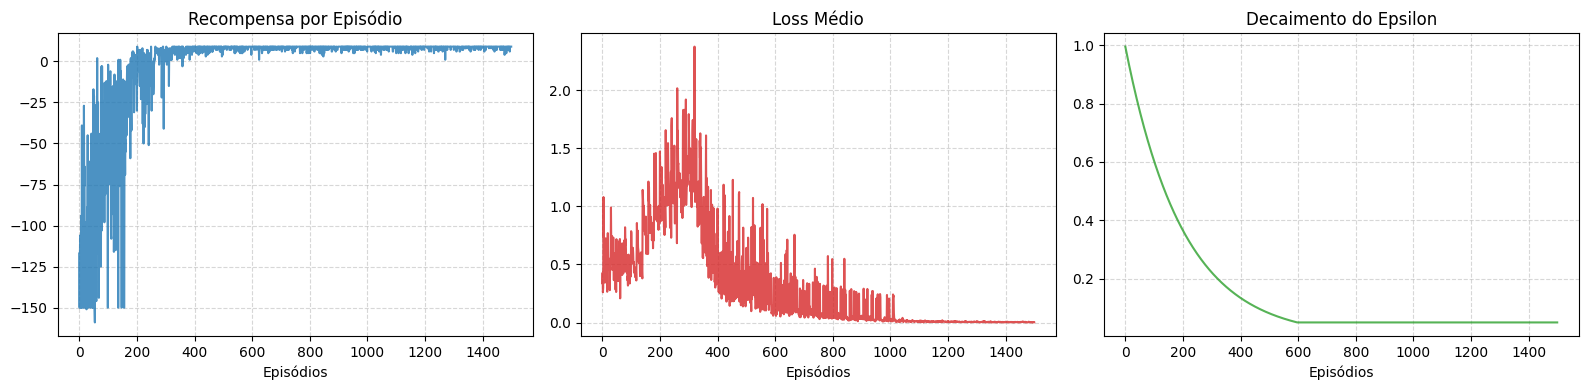

Progresso: Episódio  1500/1500
Métricas (últimos 100 ep): Recompensa Média:    8.5 | Taxa de Sucesso: 100.0% | Epsilon Atual: 0.050

Treinamento concluído. O agente alcançou estabilidade nas métricas acima.
Taxa de sucesso final (últimos 200 ep.): 100.0%


In [22]:
q_net, target_net = criar_redes()
optimizer = optim.Adam(q_net.parameters(), lr=LR)
buffer    = ReplayBuffer(BUFFER_SIZE)

# Histórico
hist_reward  = []
hist_steps   = []
hist_loss    = []
hist_epsilon = []
hist_sucesso = []

epsilon = EPS_START

for ep in range(N_EPISODES):
    state        = START
    total_reward = 0
    steps        = 0
    ep_losses    = []
    chegou       = False

    for _ in range(MAX_STEPS):
        # 1) Escolhe ação (ε-greedy)
        if random.random() < epsilon:
            action = random.choice(ACTIONS)
        else:
            with torch.no_grad():
                s_t    = encode_state(state).unsqueeze(0)
                action = int(q_net(s_t).argmax().item())

        # 2) Executa no ambiente
        next_state, reward, done = step(state, action)

        # 3) Salva no replay buffer
        buffer.push(
            encode_state(state),
            action,
            reward,
            encode_state(next_state),
            float(done)
        )

        # 4) Treina a q_net
        loss = treinar_passo(q_net, target_net, optimizer, buffer, BATCH_SIZE, GAMMA)
        if loss is not None:
            ep_losses.append(loss)

        total_reward += reward
        steps        += 1
        state         = next_state

        if done:
            chegou = (next_state == GOAL)
            break

    # 5) Atualiza target_net periodicamente
    if (ep + 1) % TARGET_UPDATE == 0:
        atualizar_target(q_net, target_net)

    # 6) Decai epsilon
    epsilon = max(EPS_MIN, epsilon * EPS_DECAY)

    hist_reward.append(total_reward)
    hist_steps.append(steps)
    hist_loss.append(np.mean(ep_losses) if ep_losses else 0)
    hist_epsilon.append(epsilon)
    hist_sucesso.append(int(chegou))

    # Atualiza os gráficos e as métricas a cada 100 episódios
    if (ep + 1) % 100 == 0:
        clear_output(wait=True) # Limpa a célula de saída atual

        fig, axs = plt.subplots(1, 3, figsize=(16, 4))

        axs[0].plot(hist_reward, color='#1f77b4', alpha=0.8)
        axs[0].set_title('Recompensa por Episódio')
        axs[0].set_xlabel('Episódios')
        axs[0].grid(True, linestyle='--', alpha=0.5)

        axs[1].plot(hist_loss, color='#d62728', alpha=0.8)
        axs[1].set_title('Loss Médio')
        axs[1].set_xlabel('Episódios')
        axs[1].grid(True, linestyle='--', alpha=0.5)

        axs[2].plot(hist_epsilon, color='#2ca02c', alpha=0.8)
        axs[2].set_title('Decaimento do Epsilon')
        axs[2].set_xlabel('Episódios')
        axs[2].grid(True, linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.show()

        taxa = np.mean(hist_sucesso[-100:]) * 100
        print(f'Progresso: Episódio {ep+1:5d}/{N_EPISODES}')
        print(f'Métricas (últimos 100 ep): Recompensa Média: {np.mean(hist_reward[-100:]):6.1f} | '
              f'Taxa de Sucesso: {taxa:5.1f}% | Epsilon Atual: {epsilon:.3f}')

print('\nTreinamento concluído. O agente alcançou estabilidade nas métricas acima.')
print(f'Taxa de sucesso final (últimos 200 ep.): {np.mean(hist_sucesso[-200:])*100:.1f}%')

---
## 8. Analisando o Aprendizado

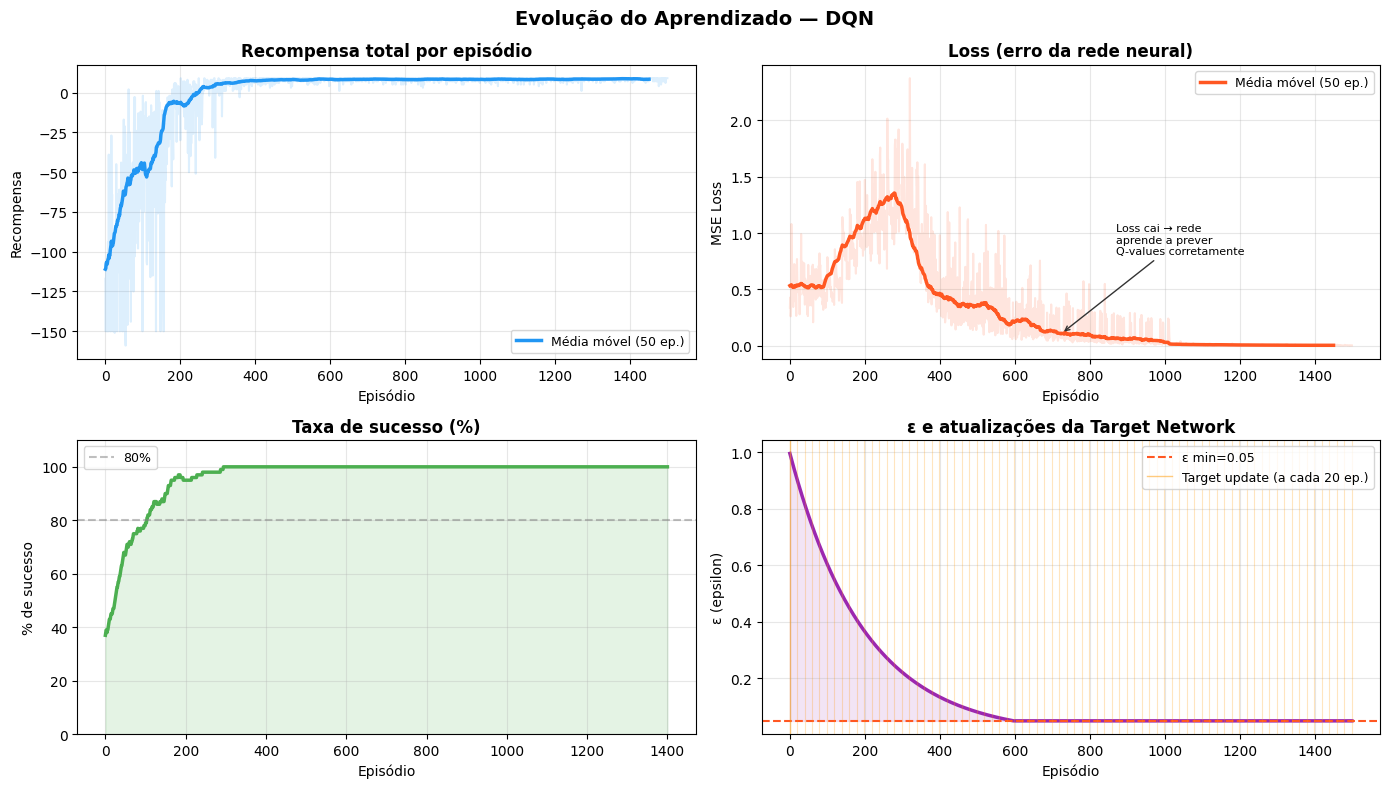

In [23]:
def media_movel(dados, janela=50):
    return np.convolve(dados, np.ones(janela)/janela, mode='valid')


fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Evolução do Aprendizado — DQN', fontsize=14, fontweight='bold')

# 1) Recompensa
ax = axes[0, 0]
ax.plot(hist_reward, alpha=0.15, color='#2196F3')
ax.plot(media_movel(hist_reward), color='#2196F3', linewidth=2.5, label='Média móvel (50 ep.)')
ax.set_title('Recompensa total por episódio', fontweight='bold')
ax.set_xlabel('Episódio'); ax.set_ylabel('Recompensa')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# 2) Loss
ax = axes[0, 1]
ax.plot(hist_loss, alpha=0.15, color='#FF5722')
mm_loss = media_movel(hist_loss)
ax.plot(mm_loss, color='#FF5722', linewidth=2.5, label='Média móvel (50 ep.)')
ax.set_title('Loss (erro da rede neural)', fontweight='bold')
ax.set_xlabel('Episódio'); ax.set_ylabel('MSE Loss')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.annotate('Loss cai → rede\naprende a prever\nQ-values corretamente',
            xy=(len(mm_loss)//2, mm_loss[len(mm_loss)//2]),
            xytext=(len(mm_loss)*0.6, mm_loss.max()*0.6),
            arrowprops=dict(arrowstyle='->', color='#333'),
            fontsize=8)

# 3) Taxa de sucesso
ax = axes[1, 0]
taxa = media_movel(hist_sucesso, janela=100) * 100
ax.plot(taxa, color='#4CAF50', linewidth=2.5)
ax.fill_between(range(len(taxa)), taxa, alpha=0.15, color='#4CAF50')
ax.axhline(80, color='gray', linestyle='--', alpha=0.5, label='80%')
ax.set_title('Taxa de sucesso (%)', fontweight='bold')
ax.set_xlabel('Episódio'); ax.set_ylabel('% de sucesso')
ax.set_ylim(0, 110); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# 4) Epsilon
ax = axes[1, 1]
ax.plot(hist_epsilon, color='#9C27B0', linewidth=2.5)
ax.fill_between(range(len(hist_epsilon)), hist_epsilon, EPS_MIN,
                alpha=0.12, color='#9C27B0')
ax.axhline(EPS_MIN, color='#FF5722', linestyle='--', label=f'ε min={EPS_MIN}')

# Marca os momentos de atualização da target network
for ep in range(TARGET_UPDATE - 1, N_EPISODES, TARGET_UPDATE):
    ax.axvline(ep, color='#FF9800', alpha=0.25, linewidth=0.8)
ax.axvline(0, color='#FF9800', alpha=0.5, linewidth=1,
           label=f'Target update (a cada {TARGET_UPDATE} ep.)')

ax.set_title('ε e atualizações da Target Network', fontweight='bold')
ax.set_xlabel('Episódio'); ax.set_ylabel('ε (epsilon)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Política Aprendida e Caminho Ótimo

/tmp/ipykernel_2048/1878279723.py:60: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


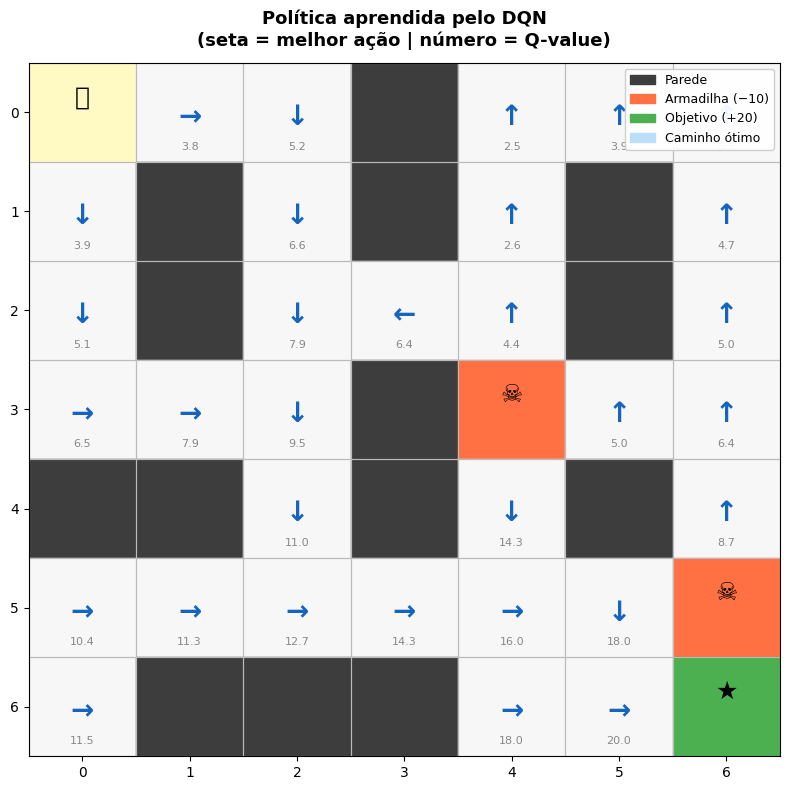

In [16]:
def get_q_table_from_dqn(q_net):
    """Extrai os Q-values da rede para todos os estados — para visualização."""
    Q = np.zeros((ROWS, COLS, N_ACTIONS))
    q_net.eval()
    with torch.no_grad():
        for r in range(ROWS):
            for c in range(COLS):
                if MAZE[r, c] != 1:
                    s   = encode_state((r, c)).unsqueeze(0)
                    Q[r, c] = q_net(s).cpu().numpy()
    return Q


def plot_maze_dqn(Q, path=None, title='Labirinto'):
    """Visualiza o labirinto com a política aprendida pelo DQN."""
    fig, ax = plt.subplots(figsize=(8, 8))
    CELL_COLORS = {0:'#f7f7f7', 1:'#3d3d3d', 2:'#FF7043', 3:'#4CAF50'}

    for r in range(ROWS):
        for c in range(COLS):
            ct    = MAZE[r, c]
            color = CELL_COLORS[ct]
            if path and (r, c) in path and ct == 0: color = '#BBDEFB'
            if (r, c) == START: color = '#FFF9C4'

            ax.add_patch(plt.Rectangle((c, ROWS-r-1), 1, 1, color=color, zorder=1))
            ax.add_patch(plt.Rectangle((c, ROWS-r-1), 1, 1, fill=False,
                                       edgecolor='#bbbbbb', linewidth=0.8, zorder=2))

            icon = {1:'', 2:'☠', 3:'★'}.get(ct, '')
            if (r, c) == START: icon = '🚀'
            if icon:
                ax.text(c+0.5, ROWS-r-0.35, icon, ha='center', va='center',
                        fontsize=18, zorder=4)

            if ct == 0 and (r, c) != START:
                best_a = int(np.argmax(Q[r, c]))
                best_q = np.max(Q[r, c])
                ax.text(c+0.5, ROWS-r-0.55, ACTION_ARROWS[best_a],
                        ha='center', va='center', fontsize=20,
                        color='#1565C0', fontweight='bold', zorder=3)
                ax.text(c+0.5, ROWS-r-0.85, f'{best_q:.1f}',
                        ha='center', va='center', fontsize=8, color='#888', zorder=3)

            if path and (r, c) in path:
                ax.plot(c+0.5, ROWS-r-0.5, 'o', color='#1565C0',
                        markersize=8, zorder=5, alpha=0.6)

    ax.set_xlim(0, COLS); ax.set_ylim(0, ROWS)
    ax.set_xticks(np.arange(COLS)+0.5); ax.set_yticks(np.arange(ROWS)+0.5)
    ax.set_xticklabels(range(COLS)); ax.set_yticklabels(range(ROWS-1,-1,-1))
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    legend = [
        mpatches.Patch(color='#3d3d3d', label='Parede'),
        mpatches.Patch(color='#FF7043', label='Armadilha (−10)'),
        mpatches.Patch(color='#4CAF50', label='Objetivo (+20)'),
        mpatches.Patch(color='#BBDEFB', label='Caminho ótimo'),
    ]
    ax.legend(handles=legend, loc='upper right', fontsize=9, framealpha=0.95)
    plt.tight_layout(); plt.show()


Q_dqn = get_q_table_from_dqn(q_net)
plot_maze_dqn(Q_dqn, title='Política aprendida pelo DQN\n(seta = melhor ação | número = Q-value)')

Simulando o agente DQN treinado (ε = 0):
-------------------------------------------------------
  Passo  1: (0, 0) →[→]→ (0, 1) | r=-1 | Q=[1.71 2.74 1.58 2.91] 
  Passo  2: (0, 1) →[→]→ (0, 2) | r=-1 | Q=[2.58 2.84 1.59 3.85] 
  Passo  3: (0, 2) →[↓]→ (1, 2) | r=-1 | Q=[3.95 5.21 2.7  3.85] 
  Passo  4: (1, 2) →[↓]→ (2, 2) | r=-1 | Q=[4.13 6.56 5.03 5.17] 
  Passo  5: (2, 2) →[↓]→ (3, 2) | r=-1 | Q=[5.28 7.92 6.35 5.31] 
  Passo  6: (3, 2) →[↓]→ (4, 2) | r=-1 | Q=[6.5  9.47 6.47 8.04] 
  Passo  7: (4, 2) →[↓]→ (5, 2) | r=-1 | Q=[ 8.31 10.96  8.91  9.7 ] 
  Passo  8: (5, 2) →[→]→ (5, 3) | r=-1 | Q=[ 9.67 10.9   9.83 12.7 ] 
  Passo  9: (5, 3) →[→]→ (5, 4) | r=-1 | Q=[11.93 12.66 11.3  14.27] 
  Passo 10: (5, 4) →[→]→ (5, 5) | r=-1 | Q=[12.7  16.04 12.93 16.05] 
  Passo 11: (5, 5) →[↓]→ (6, 5) | r=-1 | Q=[16.03 17.95 14.32 -9.84] 
  Passo 12: (6, 5) →[→]→ (6, 6) | r=+20 | Q=[15.9  17.92 15.82 20.02] ★
-------------------------------------------------------
Resultado : ✅ Objetivo!
Passo

/tmp/ipykernel_2048/1878279723.py:60: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


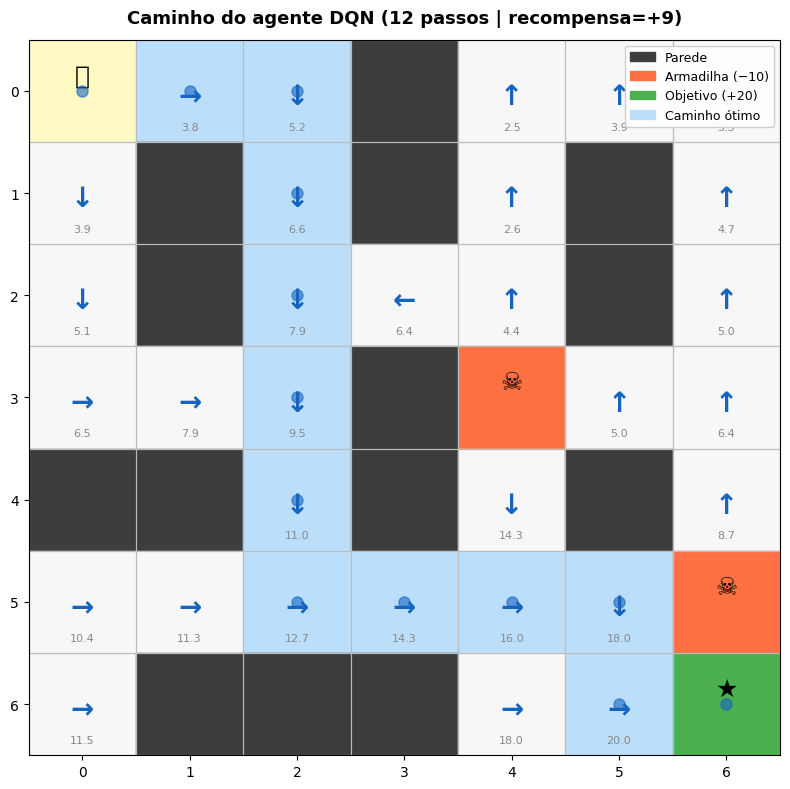

In [17]:
def simular_dqn(q_net, verbose=True):
    """Simula o agente DQN treinado (sem exploração)."""
    q_net.eval()
    state = START
    path  = [state]
    total_reward = 0

    if verbose:
        print('Simulando o agente DQN treinado (ε = 0):')
        print('-' * 55)

    for n in range(60):
        with torch.no_grad():
            s_t    = encode_state(state).unsqueeze(0)
            q_vals = q_net(s_t)[0].cpu().numpy()
            action = int(np.argmax(q_vals))

        next_state, reward, done = step(state, action)
        total_reward += reward
        path.append(next_state)

        if verbose:
            tipo = '☠' if MAZE[next_state] == 2 else ('★' if next_state == GOAL else '')
            print(f'  Passo {n+1:2d}: {state} →[{ACTION_ARROWS[action]}]→ {next_state} '
                  f'| r={reward:+d} | Q={q_vals.round(2)} {tipo}')

        state = next_state
        if done:
            break

    sucesso = (state == GOAL)
    if verbose:
        print('-' * 55)
        print(f'Resultado : {"✅ Objetivo!" if sucesso else "❌ Não chegou"}')
        print(f'Passos    : {len(path)-1}')
        print(f'Recompensa: {total_reward:+d}')
    return path, sucesso, total_reward


caminho, sucesso, recomp = simular_dqn(q_net)
Q_dqn = get_q_table_from_dqn(q_net)
plot_maze_dqn(Q_dqn, path=caminho,
              title=f'Caminho do agente DQN ({len(caminho)-1} passos | recompensa={recomp:+d})')

---
## 10. DQN vs Q-Learning — Comparação Direta

Treinando Q-Learning para comparação...
✅ Pronto!


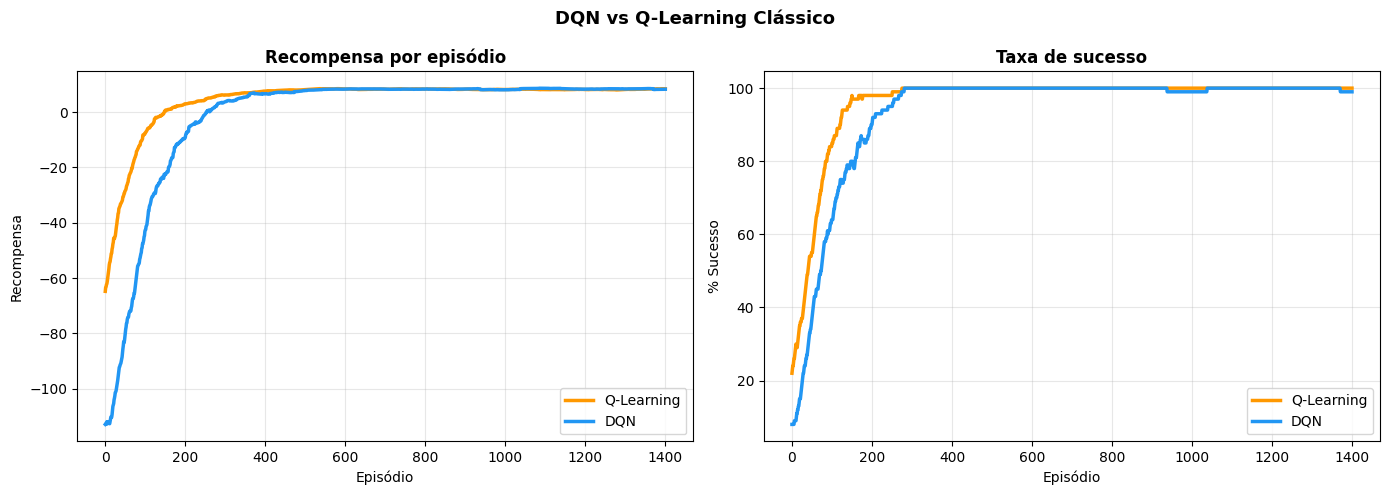


Observação: neste labirinto pequeno, ambos convergem.
A vantagem do DQN aparece em ambientes de alta dimensionalidade,
onde a tabela Q seria inviável (jogos, robótica, etc.).


In [18]:
# Treina Q-Learning clássico para comparar
def treinar_qlearning(n_ep=1500, alpha=0.1, gamma=0.95,
                       eps_start=1.0, eps_min=0.05, eps_decay=0.995):
    random.seed(SEED); np.random.seed(SEED)
    Q_tab  = np.zeros((ROWS, COLS, N_ACTIONS))
    eps    = eps_start
    hist_r = []
    hist_s = []
    for _ in range(n_ep):
        state = START
        total = 0
        for _ in range(150):
            r, c   = state
            action = random.choice(ACTIONS) if random.random() < eps \
                     else int(np.argmax(Q_tab[r, c]))
            ns, reward, done = step(state, action)
            nr, nc = ns
            Q_tab[r,c,action] += alpha*(reward + gamma*np.max(Q_tab[nr,nc]) - Q_tab[r,c,action])
            total += reward
            state  = ns
            if done:
                break
        eps = max(eps_min, eps * eps_decay)
        hist_r.append(total)
        hist_s.append(int(state == GOAL))
    return hist_r, hist_s


print('Treinando Q-Learning para comparação...')
ql_reward, ql_sucesso = treinar_qlearning()
print('✅ Pronto!')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DQN vs Q-Learning Clássico', fontsize=13, fontweight='bold')

for ax, (ql_h, dqn_h, ylabel, title) in zip(axes, [
    (ql_reward, hist_reward, 'Recompensa', 'Recompensa por episódio'),
    (ql_sucesso, hist_sucesso, '% Sucesso', 'Taxa de sucesso'),
]):
    ql_mm  = media_movel(ql_h,  100)
    dqn_mm = media_movel(dqn_h, 100)
    if ylabel == '% Sucesso':
        ql_mm  = ql_mm  * 100
        dqn_mm = dqn_mm * 100

    ax.plot(ql_mm,  color='#FF9800', linewidth=2.5, label='Q-Learning')
    ax.plot(dqn_mm, color='#2196F3', linewidth=2.5, label='DQN')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Episódio'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\nObservação: neste labirinto pequeno, ambos convergem.')
print('A vantagem do DQN aparece em ambientes de alta dimensionalidade,')
print('onde a tabela Q seria inviável (jogos, robótica, etc.).')

---
## 11. Resumo Completo — MDP → Q-Learning → DQN

| | MDP | Q-Learning | DQN |
|---|---|---|---|
| **Conhece o ambiente?** | ✅ Sim | ❌ Não | ❌ Não |
| **O que armazena?** | V(s) | Tabela Q(s,a) | Pesos da rede neural |
| **Escala para estados grandes?** | ❌ Não | ❌ Não | ✅ Sim |
| **Generaliza entre estados?** | ❌ Não | ❌ Não | ✅ Sim |
| **Precisa de GPU?** | Não | Não | Recomendado |
| **Exemplo de uso** | Labirinto simples | Labirinto médio | Atari, robótica |

### Os dois truques do DQN — por que são necessários?

```
Problema 1: Dados correlacionados
→ Solução: Experience Replay — amostragem aleatória do buffer

Problema 2: Alvo instável
→ Solução: Target Network — cópia congelada atualizada a cada C passos
```

### O que vem depois do DQN?

- **Double DQN**: corrige o viés de superestimação dos Q-values
- **Dueling DQN**: separa V(s) e vantagem A(s,a) na arquitetura
- **Prioritized Replay**: amostra experiências mais importantes com mais frequência
- **Rainbow**: combina todas as melhorias acima
- **Policy Gradient / PPO / SAC**: abordagens que aprendem a política diretamente, sem Q-table

In [19]:
# Comparação de escala: Q-table vs rede neural
print('=== Comparação de escala ===')
print()
print('Nosso labirinto 7×7:')
print(f'  Q-table   : {ROWS*COLS*N_ACTIONS} valores')
n_params = sum(p.numel() for p in q_net.parameters())
print(f'  DQN (rede): {n_params:,} parâmetros')
print()
print('Jogo de Atari (tela 84×84 cinza, stack de 4 frames):')
atari_states = 84 * 84 * 4
print(f'  Dimensão do estado  : {atari_states:,}')
print(f'  Q-table impossível  : 256^{atari_states} entradas')
print(f'  DQN (DeepMind 2015) : ~1.7 milhões de parâmetros — viável!')
print()
print('→ A rede neural generaliza: aprendeu que estados parecidos')
print('  têm Q-values parecidos — a tabela nunca consegue isso.')

=== Comparação de escala ===

Nosso labirinto 7×7:
  Q-table   : 196 valores
  DQN (rede): 4,612 parâmetros

Jogo de Atari (tela 84×84 cinza, stack de 4 frames):
  Dimensão do estado  : 28,224
  Q-table impossível  : 256^28224 entradas
  DQN (DeepMind 2015) : ~1.7 milhões de parâmetros — viável!

→ A rede neural generaliza: aprendeu que estados parecidos
  têm Q-values parecidos — a tabela nunca consegue isso.
